In [4]:
%run general_functions.ipynb

In [5]:
vars = {
            'ALK': {'var_name': 'ALK',      'long': 'Alkalinity',                 'unit': r'μ mol $\mathregular{kg^{-1}}$'},
            'DIC': {'var_name': 'DIC',      'long': 'Dissolved Inorganic Carbon', 'unit': r'μ mol $\mathregular{kg^{-1}}$'},
            'mld': {'var_name': 'somxl010', 'long': 'Mixed Layer Depth',          'unit': r'm'},
}

scenarios = {'126':'SSP1-2.6','370':'SSP3-7.0'}
sims = {'baseline':'Baseline','oae':'OAE'}

weights = (grid_cell_ocean.sel(x=slice(520, 595), y=slice(330, 435))).fillna(0)

alk_mask = xr.open_dataset(data_path + '../alk_mask/alkalinity_mask_timeseries.nc')['alk_flux'].sum('time_counter')
alk_mask = alk_mask.where(alk_mask)
alk_mask = (alk_mask.sel(x=slice(520, 595), y=slice(330, 435))).fillna(0)

month_label = ['J','F','M','A','M','J','J','A','S','O','N','D']

In [247]:
# EUROPEAN AVERAGE
    
def hovmoller_depth(location):
    for scen, scen_name in scenarios.items():
        fig, axes = plt.subplots(
            2, 2,
            sharex=True,
            figsize=(14,6),
            gridspec_kw={'height_ratios':[1,2], 'hspace':0.05, 'wspace':0.06}
        )
    
        for col, (sim, sim_name) in enumerate(sims.items()):
    
            ax_top = axes[0, col]
            ax_bot = axes[1, col]
    
            cmap = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True)
            cmap, norm = create_discrete_cmap(cmap, 30)
        
            # ---- Load datasets

            mld = xr.open_dataset(f"{data_path}mld_{sim}_{scen}.nc")
            if location == 'Coastline':
                mld = mld.where(alk_mask)
    
            weighted = mld.weighted(weights).mean(('x','y'))
            final_mld = seasonal_avg(weighted, 'somxl010')
            mld_final[sim] = final_mld
    
            var = 'ALK'
            alkalinity = xr.open_dataset(f"{data_path}{var}_{sim}_{scen}.nc")
            if location == 'Coastline':
                alkalinity = alkalinity.where(alk_mask)
    
            weighted = alkalinity.weighted(weights).mean(('x','y'))
            final = seasonal_avg(weighted, var)
            final = final.where(final['deptht'] < final_mld['somxl010'], drop=True)
    
            vmin_top = float(final[var].sel(deptht=slice(0,20)).min())
            vmax_top = float(final[var].sel(deptht=slice(0,20)).max())
            # ---- Plot
            im_top = final[var].T.plot(
                ax=ax_top,
                # vmin=vmin_top,
                # vmax=vmax_top,
                # cmap=cmap,
                add_colorbar=False
            )
            
            vmin_bot = float(final[var].sel(deptht=slice(20,None)).min())
            vmax_bot = float(final[var].sel(deptht=slice(20,None)).max())
            
            im_bot = final[var].T.plot(
                ax=ax_bot,
                # vmin=vmin_bot,
                # vmax=vmax_bot,
                # cmap=cmap,
                add_colorbar=False
            )
            # ---- Broken axis limits
            first_level = final['deptht'][0]
            ax_top.set_ylim(first_level,0)
            ax_bot.set_ylim(150,first_level)
    
            # ---- Hide connecting spines
            ax_top.spines['bottom'].set_visible(False)
            ax_bot.spines['top'].set_visible(False)
    
            ax_top.set_title(sim_name)
    
            # ---- Break marks
            d = .3
            kwargs = dict(marker=[(-1,-d),(1,d)], markersize=12,
                          linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    
            for ax in [ax_top,ax_bot]:
                ax.set_xticks(np.arange(1, 13, 1))
                ax.set_xticklabels(month_label, fontsize=16)
    
                ax.set_ylabel('Depth [ m ]')
                ax.set_xlabel('')
    
                map_outlook(ax,12)
    
            if col == 1:
                for ax in [ax_top, ax_bot]:
                    ax.set_ylabel('')
                    ax.tick_params(axis='y', labelleft=False)
                
        cb_top = fig.colorbar(im_top, ax=axes[0,:], extend='both', location='right', aspect=7.5, pad=0.02)
        cb_bot = fig.colorbar(im_bot, ax=axes[1,:], extend='both', location='right', aspect=15, pad=0.02)
    
        for cb in [cb_top, cb_bot]:
            for label in (cb.ax.get_xticklabels() + cb.ax.get_yticklabels() + [cb.ax.title, cb.ax.xaxis.label, cb.ax.yaxis.label]):
                label.set_fontproperties(font_prop)
                label.set_fontsize(12)
            cb.outline.set_linewidth(0.25)
            
        cb_top.set_label(f'{vars[var]["long"]} [ {vars[var]["unit"]} ]')
        
        fig.suptitle(f"{scen_name}", y=0.95)
        # plt.savefig(f'/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/figure_alk_mld_{scen}_{location}.png')

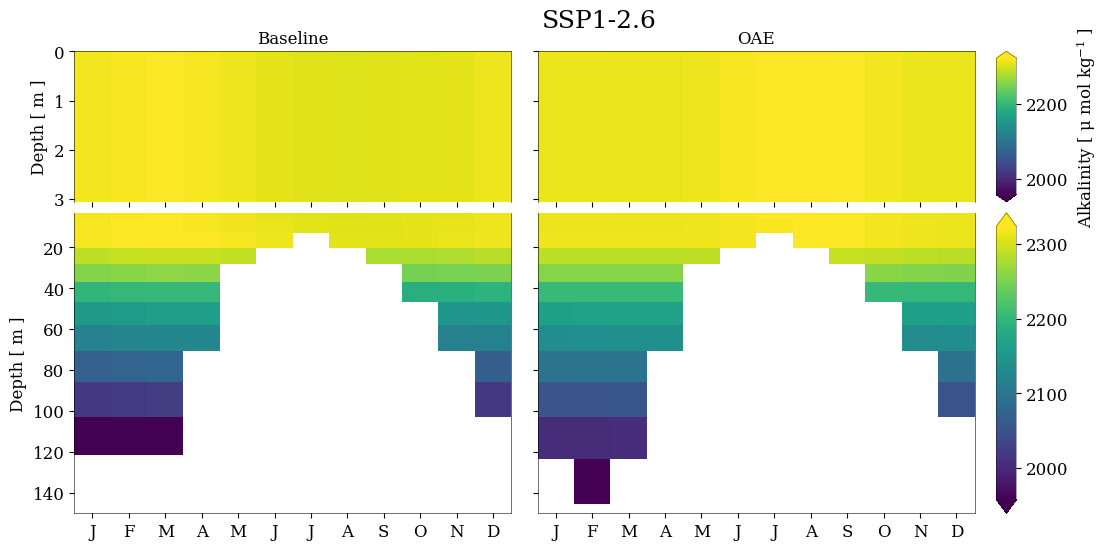

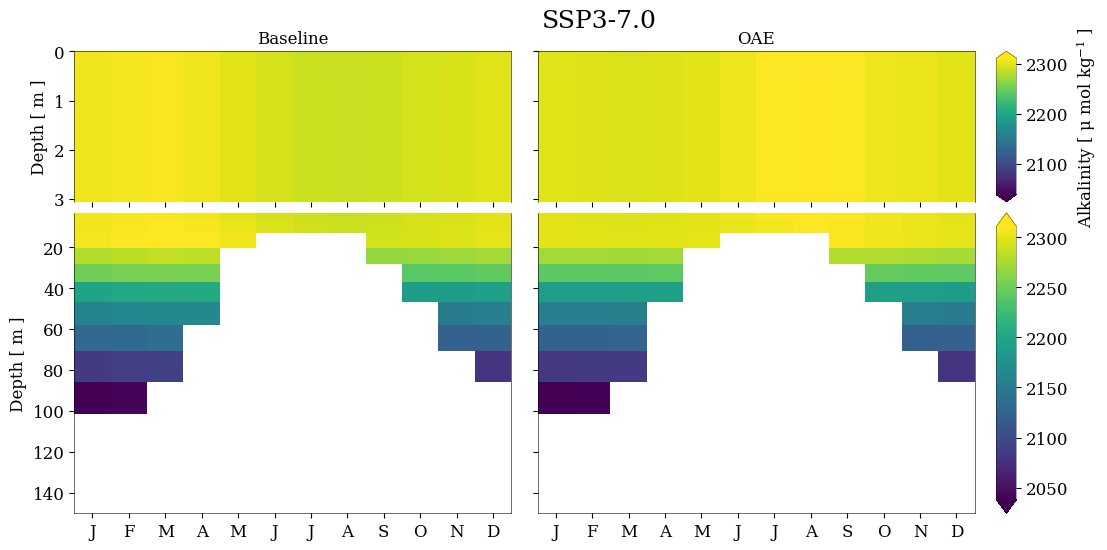

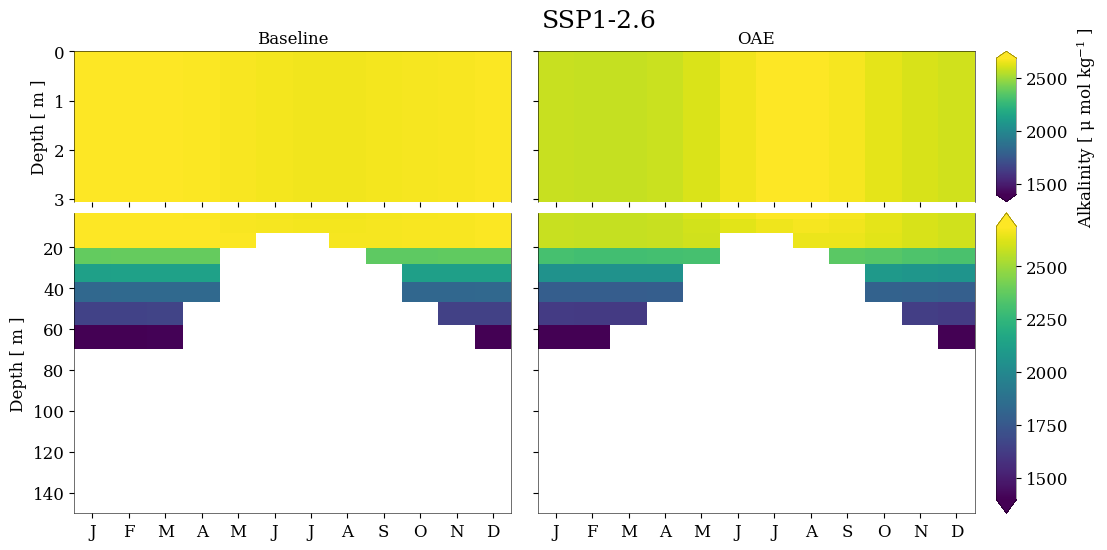

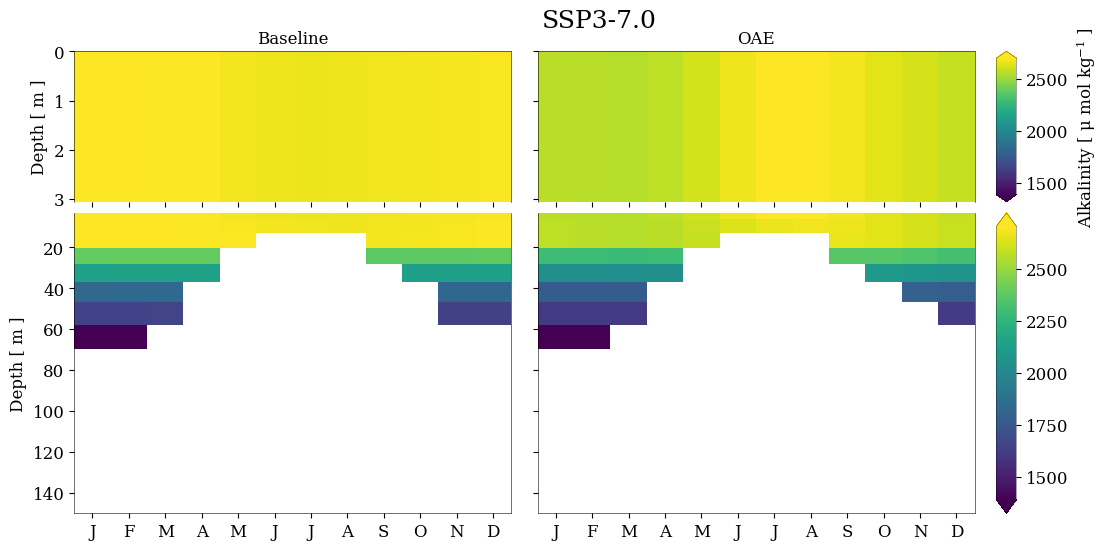

In [203]:
hovmoller_depth('europe')
hovmoller_depth('coastline')

In [277]:
def hovmoller_difference(location, vmin, vmax):
    fig, axes = plt.subplots(
        2, len(scenarios),
        sharex=True,
        figsize=(12,6),
        gridspec_kw={'height_ratios':[1,2], 'hspace':0.05, 'wspace':0.05}
    )
    
    for col, (scen, scen_name) in enumerate(scenarios.items()):
    
        sim_final = {}
        mld_final = {}
    
        ax_top = axes[0, col]
        ax_bot = axes[1, col]
    
        for sim, sim_name in sims.items():
    
            cmap = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True)
            cmap, norm = create_discrete_cmap(cmap, 30)
    
            # ---- Load datasets
            mld = xr.open_dataset(f"{data_path}mld_{sim}_{scen}.nc")
            if location == 'Coastline':
                mld = mld.where(alk_mask)
    
            weighted = mld.weighted(weights).mean(('x','y'))
            final_mld = seasonal_avg(weighted, 'somxl010')
            mld_final[sim] = final_mld
    
            var = 'ALK'
            alkalinity = xr.open_dataset(f"{data_path}{var}_{sim}_{scen}.nc")
            if location == 'Coastline':
                alkalinity = alkalinity.where(alk_mask)
    
            weighted = alkalinity.weighted(weights).mean(('x','y'))
            final = seasonal_avg(weighted, var)
            final = final.where(final['deptht'] < final_mld['somxl010'], drop=True)
    
            sim_final[sim] = final
    
        baseline, oae = sim_final.keys()
        difference = sim_final[oae][var] - sim_final[baseline][var]
    
        mld_base, mld_oae = mld_final.keys()
        mld_base = mld_final[mld_base]['somxl010']
    
        # ---- TOP
        vmin_top = float(difference.sel(deptht=slice(0,4)).min())
        vmax_top = float(difference.sel(deptht=slice(0,4)).max())
    
        im_top = difference.T.plot(
            ax=ax_top,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            add_colorbar=False
        )
    
        # ---- BOTTOM
        vmin_bot = float(difference.sel(deptht=slice(4,None)).min())
        vmax_bot = float(difference.sel(deptht=slice(4,None)).max())
    
        im_bot = difference.T.plot(
            ax=ax_bot,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            add_colorbar=False
        )
    
        ax_bot.step(mld_base['month'], mld_base, color='lightcoral', where='mid', linewidth=3)
    
        # ---- Broken axis
        first_level = final['deptht'][0]
        ax_top.set_ylim(first_level, 0)
        ax_bot.set_ylim(150, first_level)
    
        ax_top.spines['bottom'].set_visible(False)
        ax_bot.spines['top'].set_visible(False)
    
        for ax in [ax_top, ax_bot]:
            ax.set_xticks(np.arange(1,13,1))
            ax.set_xticklabels(month_label, fontsize=10)
            ax.set_xlabel('')
            map_outlook(ax,12)
    
        if col != 0:
            for ax in [ax_top, ax_bot]:
                ax.set_ylabel('')
                ax.tick_params(axis='y', labelleft=False)
        else:
            ax_top.set_ylabel('Depth [ m ]')
            ax_bot.set_ylabel('Depth [ m ]')
    
        ax_top.set_title(scen_name, fontsize=14)
    
    cb = fig.colorbar(im_bot, ax=axes, aspect=20, location='right', extend='both', pad=0.02)
    cb.set_label(f'{vars[var]["long"]} [ {vars[var]["unit"]} ]')

    for label in (cb.ax.get_xticklabels() + cb.ax.get_yticklabels() + [cb.ax.title, cb.ax.xaxis.label, cb.ax.yaxis.label]):
        label.set_fontproperties(font_prop)
        label.set_fontsize(10)
    cb.outline.set_linewidth(0.25)
    
    fig.text(
        0.05, 0.5, f"{location} Avg.",
        rotation=90,
        va='center',
        ha='center',
        fontsize=14
    )
    
    plt.savefig(
        f"/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/figure_difference_{location}.png",
        dpi=300,
        bbox_inches="tight"
    )

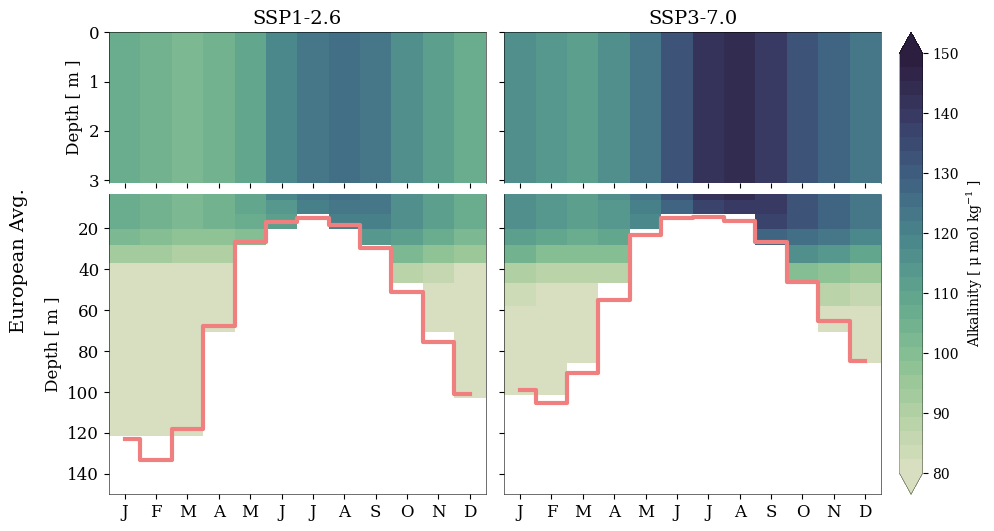

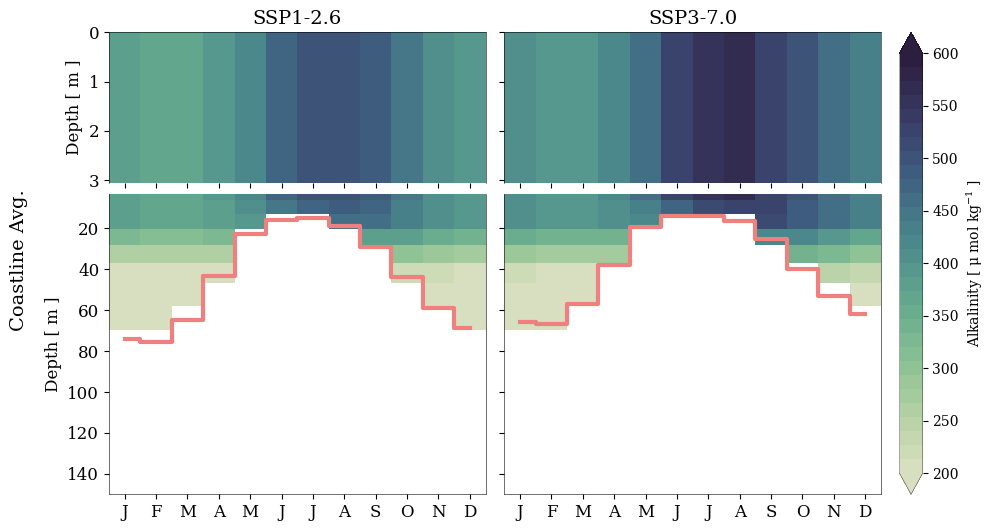

In [278]:
hovmoller_difference('European', 80, 150)
hovmoller_difference('Coastline', 200, 600)